In [30]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "fraud_detection.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jagrit31/fraud-detection",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipykernel_3474/3815705666.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'fraud-detection' dataset.


In [31]:
df.head()

,TransactionID,CustomerID,Amount,TransactionType,Location,DeviceType,TimeOfDay,PreviousFraud,TransactionSpeed,Fraud
0,1,4174,3623.044171,Withdrawal,Houston,Laptop,Morning,0,18.002612,0
1,2,4507,NaN,Deposit,Miami,Mobile,Morning,0,20.276396,0
2,3,1860,8760.570892,Purchase,Houston,ATM,Morning,0,39.389780,0
3,4,2294,7833.768690,Purchase,Miami,Laptop,Morning,0,58.910737,0
4,5,2130,1689.499795,Purchase,Los Angeles,Mobile,Afternoon,0,13.060114,0


In [32]:
df.shape

(12000, 10)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TransactionID     12000 non-null  int64  
 1   CustomerID        12000 non-null  int64  
 2   Amount            11400 non-null  float64
 3   TransactionType   12000 non-null  object 
 4   Location          12000 non-null  object 
 5   DeviceType        12000 non-null  object 
 6   TimeOfDay         12000 non-null  object 
 7   PreviousFraud     12000 non-null  int64  
 8   TransactionSpeed  12000 non-null  float64
 9   Fraud             12000 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB


In [34]:
df.describe()

,TransactionID,CustomerID,Amount,PreviousFraud,TransactionSpeed,Fraud
count,12000.00000,12000.000000,11400.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,3006.313667,5193.014661,0.239250,31.005160,0.103083
std,3464.24595,1154.224461,4636.602191,0.426643,20.083189,0.304080
min,1.00000,1000.000000,10.527741,0.000000,1.016497,0.000000
25%,3000.75000,1996.000000,2526.426451,0.000000,15.796709,0.000000
50%,6000.50000,3001.000000,5013.724064,0.000000,30.580769,0.000000
75%,9000.25000,4006.250000,7520.539997,0.000000,45.064282,0.000000
max,12000.00000,4999.000000,99869.978336,1.000000,298.753662,1.000000


In [35]:
df.isna().sum()

,0
TransactionID,0
CustomerID,0
Amount,600
TransactionType,0
Location,0
DeviceType,0
TimeOfDay,0
PreviousFraud,0
TransactionSpeed,0
Fraud,0


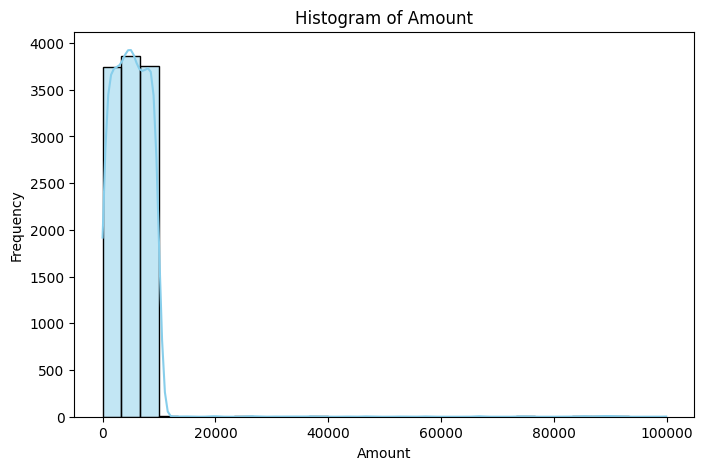

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df['Amount'], bins=30, kde=True, color='skyblue')
plt.title('Histogram of Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

In [37]:
median_value = df['Amount'].median()
df['Amount'].fillna(median_value, inplace=True)

/tmp/ipykernel_3474/3049973299.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Amount'].fillna(median_value, inplace=True)


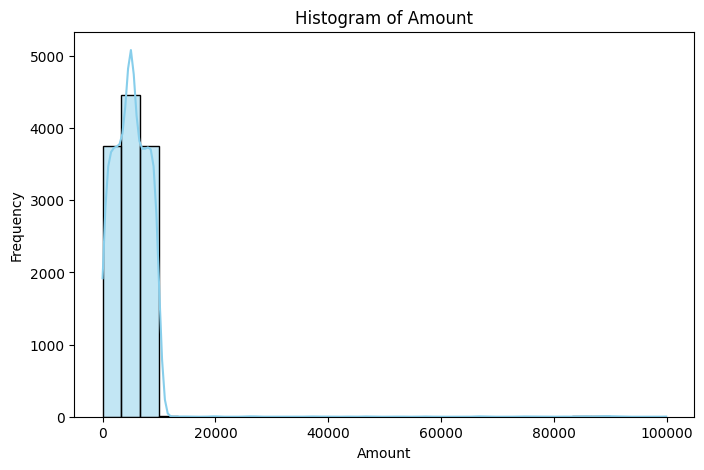

In [38]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Amount'], bins=30, kde=True, color='skyblue')
plt.title('Histogram of Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

In [39]:
df.dtypes

,0
TransactionID,int64
CustomerID,int64
Amount,float64
TransactionType,object
Location,object
DeviceType,object
TimeOfDay,object
PreviousFraud,int64
TransactionSpeed,float64
Fraud,int64


In [40]:
for col in df.columns:
    if df[col].dtype == 'object':  # cek tipe kolom
        print(f"=== Value Counts for '{col}' ===")
        print(df[col].value_counts())
        print("\n")

=== Value Counts for 'TransactionType' ===
TransactionType
Transfer      3063
Deposit       3037
Withdrawal    2955
Purchase      2945
Name: count, dtype: int64


=== Value Counts for 'Location' ===
Location
Los Angeles    2456
Miami          2419
Houston        2382
Chicago        2380
New York       2363
Name: count, dtype: int64


=== Value Counts for 'DeviceType' ===
DeviceType
Mobile    3065
Laptop    3047
ATM       2952
POS       2936
Name: count, dtype: int64


=== Value Counts for 'TimeOfDay' ===
TimeOfDay
Afternoon    4049
Morning      4011
Night        3940
Name: count, dtype: int64




/tmp/ipykernel_3474/928489765.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette="viridis", edgecolor='black')
/tmp/ipykernel_3474/928489765.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette="viridis", edgecolor='black')
/tmp/ipykernel_3474/928489765.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette="viridis", edgecolor='black')
/tmp/ipykernel_3474/928489765.py:23: FutureWarnin

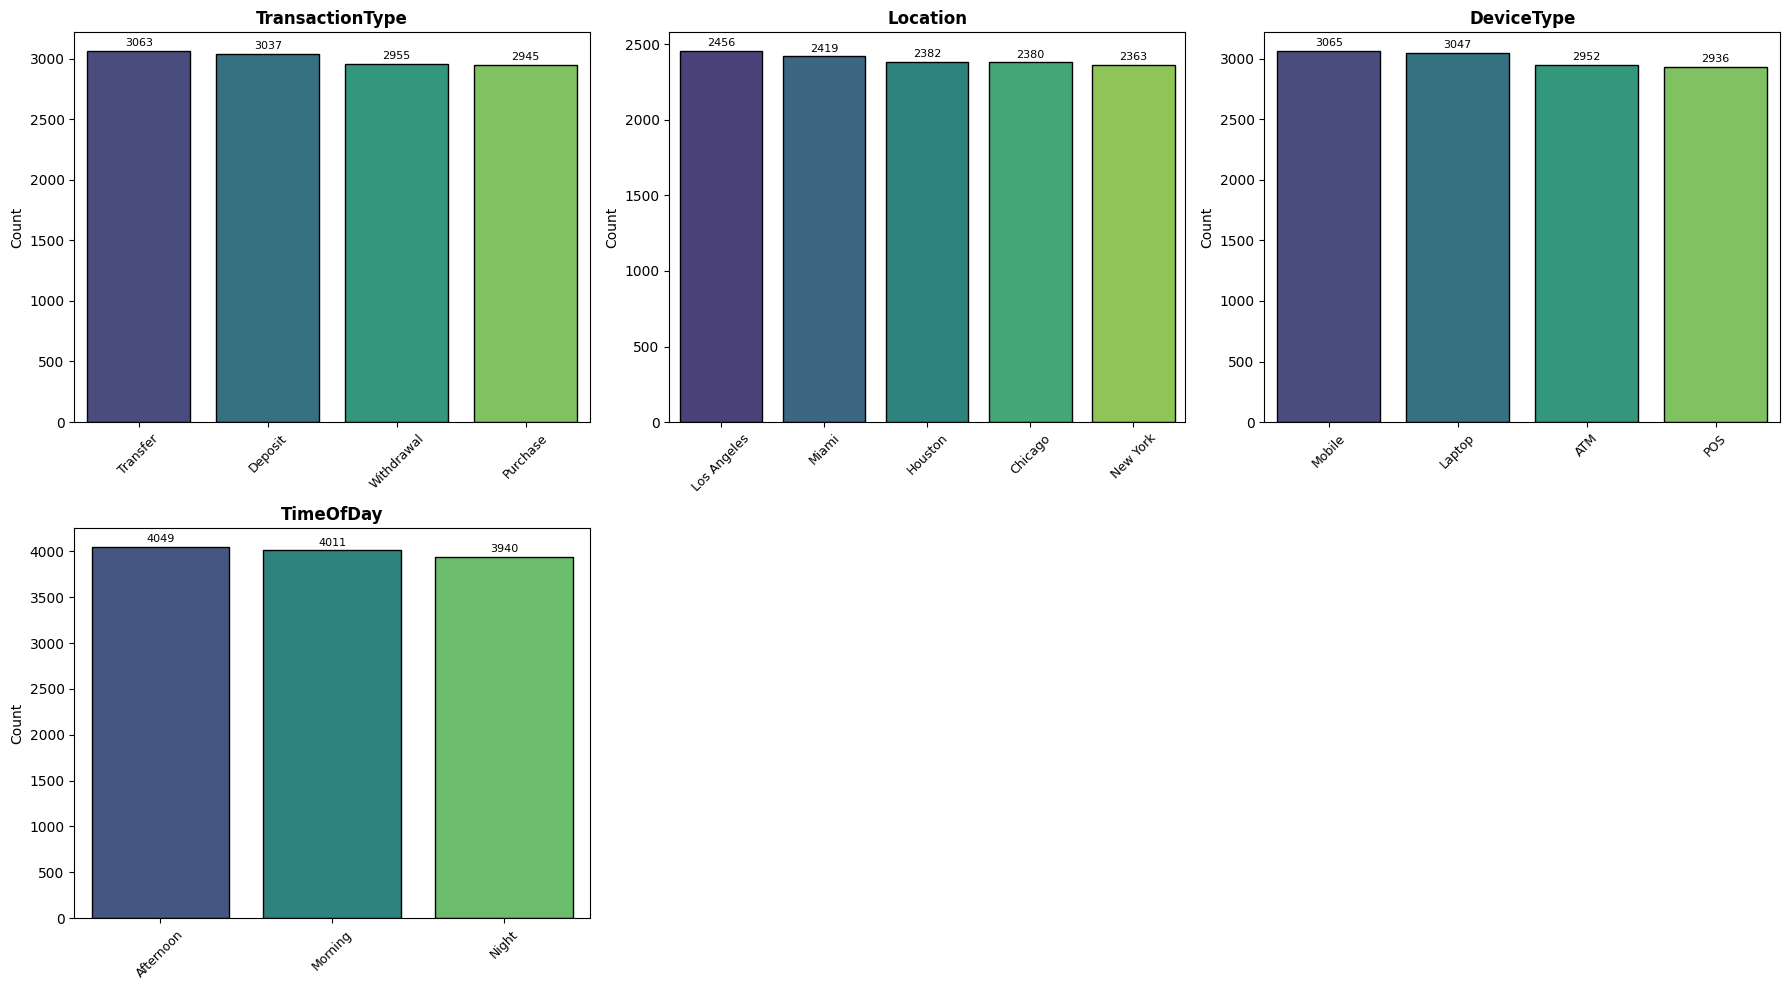

✅ Total kolom object: 4
📊 Kolom yang diplot: ['TransactionType', 'Location', 'DeviceType', 'TimeOfDay']


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil semua kolom bertipe object
object_cols = [col for col in df.columns if df[col].dtype == 'object']

# Cek apakah ada kolom object
if not object_cols:
    print("Tidak ada kolom bertipe object.")
else:
    # Atur jumlah kolom per baris
    n_cols = 3
    n_rows = (len(object_cols) + n_cols - 1) // n_cols
    
    # Buat figure dan axes
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(object_cols):
        counts = df[col].value_counts().sort_values(ascending=False)
        
        # Buat barplot
        sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette="viridis", edgecolor='black')
        
        # Formatting
        axes[i].set_title(f"{col}", fontsize=12, fontweight='bold')
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis='x', rotation=45, labelsize=9)
        
        # Tambahkan label nilai di atas bar
        for container in axes[i].containers:
            axes[i].bar_label(container, padding=2, fontsize=8)
    
    # Hapus subplot kosong jika ada
    for j in range(len(object_cols), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
    
    # Tampilkan ringkasan
    print(f"✅ Total kolom object: {len(object_cols)}")
    print(f"📊 Kolom yang diplot: {object_cols}")

In [42]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

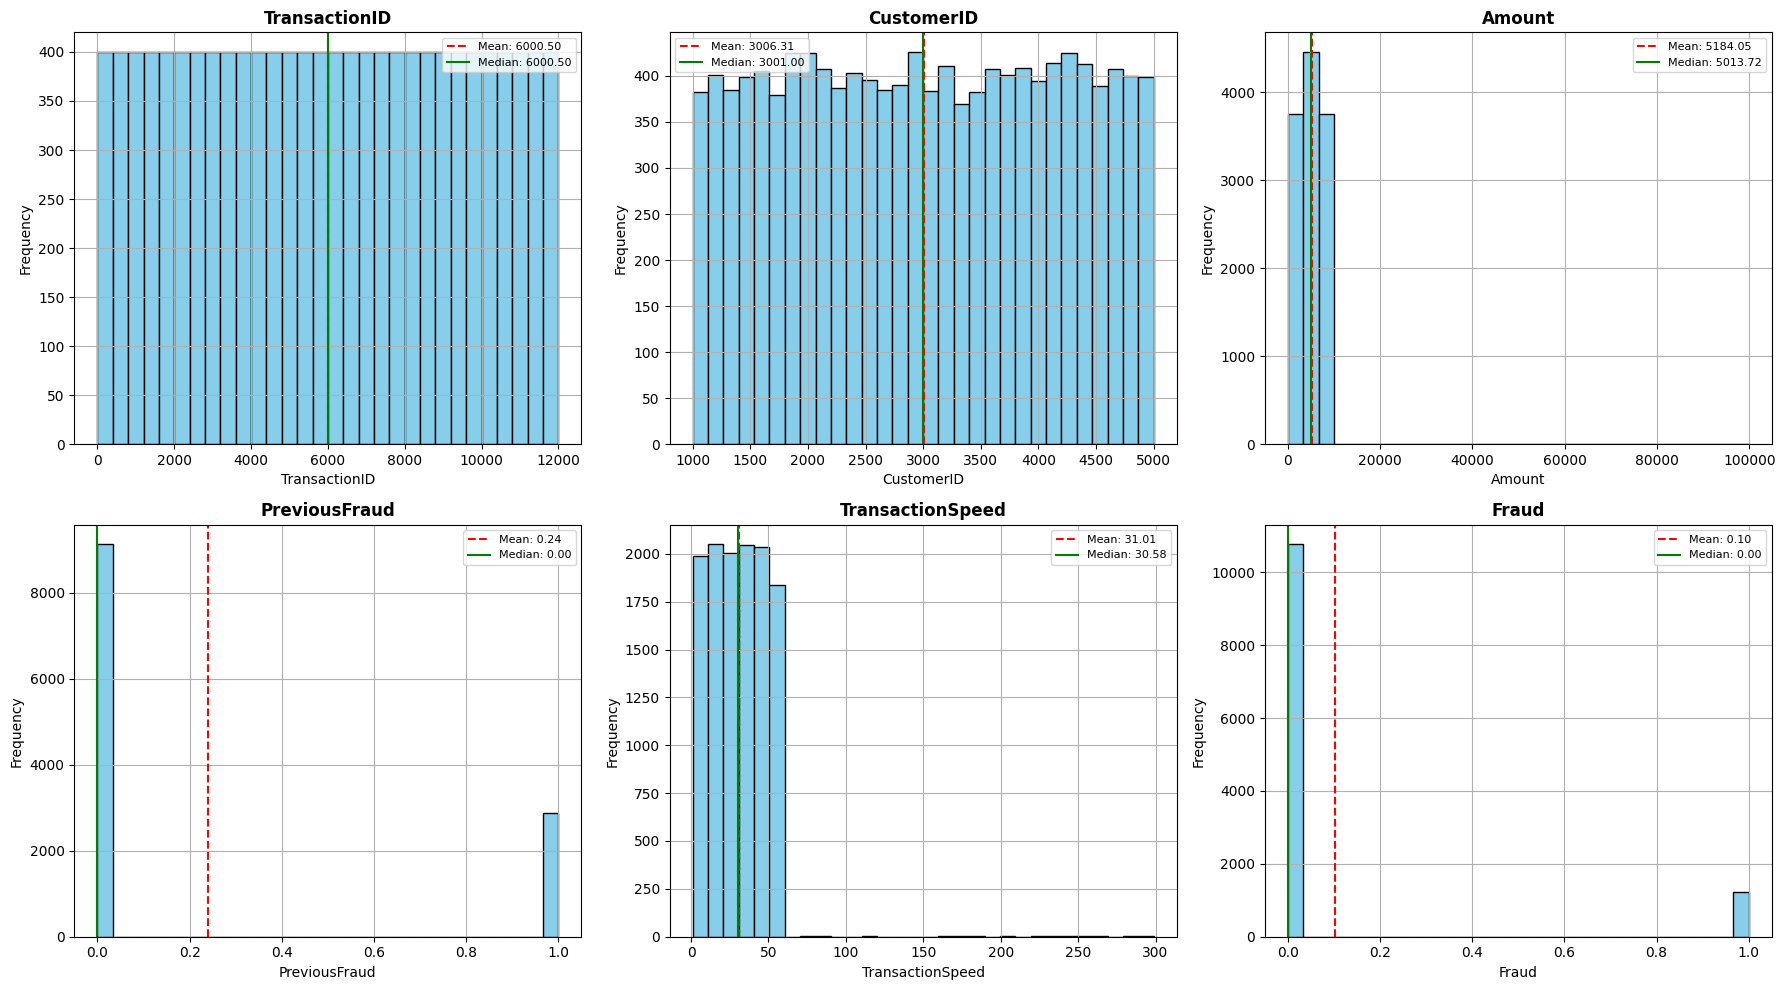

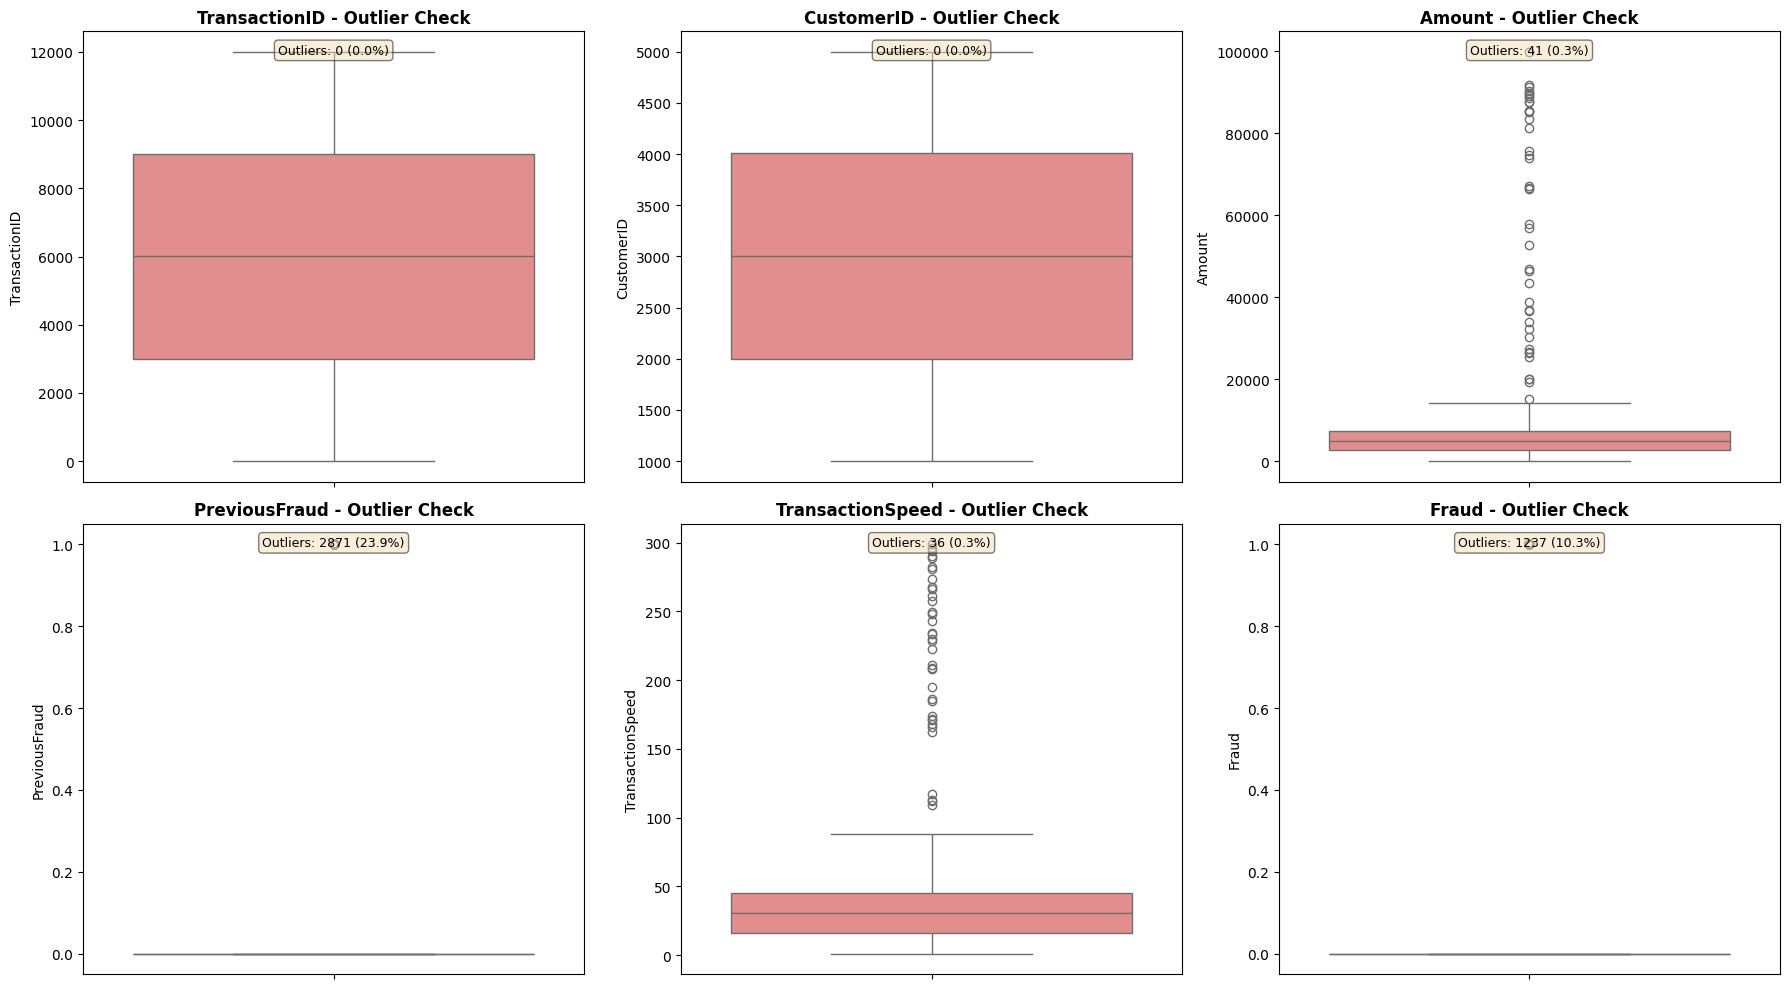

           Kolom          Q1          Q3         IQR  Lower_Bound  Upper_Bound  Jumlah_Outlier Persen_Outlier
   TransactionID 3000.750000 9000.250000 5999.500000 -5998.500000 17999.500000               0          0.00%
      CustomerID 1996.000000 4006.250000 2010.250000 -1019.375000  7021.625000               0          0.00%
          Amount 2660.725357 7375.558359 4714.833002 -4411.524145 14447.807862              41          0.34%
   PreviousFraud    0.000000    0.000000    0.000000     0.000000     0.000000            2871         23.93%
TransactionSpeed   15.796709   45.064282   29.267572   -28.104649    88.965640              36          0.30%
           Fraud    0.000000    0.000000    0.000000     0.000000     0.000000            1237         10.31%


In [43]:
import pandas as pd
if numeric_cols:
    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(numeric_cols):
        df[col].hist(ax=axes[i], bins=30, edgecolor='black', color='skyblue')
        axes[i].set_title(f"{col}", fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")
        mean_val = df[col].mean()
        median_val = df[col].median()
        axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        axes[i].axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
        axes[i].legend(fontsize=8)
    
    for j in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(numeric_cols):
        sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
        axes[i].set_title(f"{col} - Outlier Check", fontsize=12, fontweight='bold')
        axes[i].set_ylabel(col)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        axes[i].text(0.5, 0.95, f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)", 
                    transform=axes[i].transAxes, ha='center', fontsize=9, 
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    for j in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
    
    outlier_summary = []
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary.append({
            'Kolom': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Jumlah_Outlier': len(outliers),
            'Persen_Outlier': f"{len(outliers)/len(df)*100:.2f}%"
        })
    
    print(pd.DataFrame(outlier_summary).to_string(index=False))

/tmp/ipykernel_3474/392822060.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette=["skyblue", "salmon"], edgecolor='black')


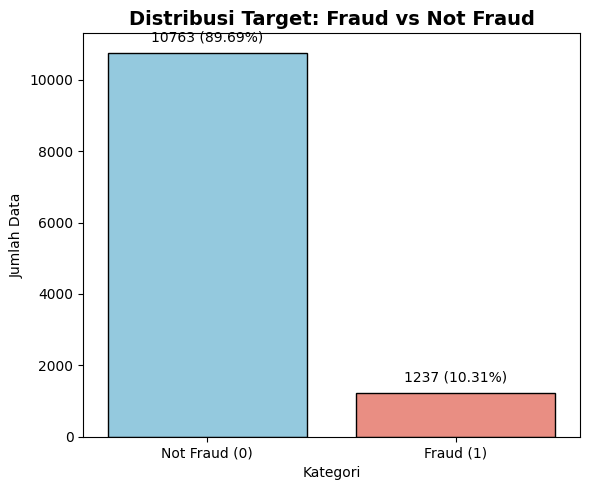


📊 Ringkasan:
   Total Data: 12000
   Fraud: 1237 (10.31%)
   Not Fraud: 10763 (89.69%)
   ⚠️  Imbalance Ratio: 8.7:1


In [44]:
plt.figure(figsize=(6, 5))

counts = df['Fraud'].value_counts().sort_index()

labels = ['Not Fraud (0)', 'Fraud (1)']

ax = sns.barplot(x=labels, y=counts.values, palette=["skyblue", "salmon"], edgecolor='black')

plt.title("Distribusi Target: Fraud vs Not Fraud", fontsize=14, fontweight='bold')
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")

for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts.values)*0.02, f"{v} ({v/len(df)*100:.2f}%)", 
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

fraud_pct = df['Fraud'].mean() * 100
print(f"\n📊 Ringkasan:")
print(f"   Total Data: {len(df)}")
print(f"   Fraud: {df['Fraud'].sum()} ({fraud_pct:.2f}%)")
print(f"   Not Fraud: {len(df) - df['Fraud'].sum()} ({100 - fraud_pct:.2f}%)")
if fraud_pct < 50:
    print(f"   ⚠️  Imbalance Ratio: {(100 - fraud_pct)/fraud_pct:.1f}:1")
else:
    print(f"   ✅ Relatively Balanced")

In [45]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours
from imblearn.combine import SMOTEENN
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

X = df.drop('Fraud', axis=1)
y = df['Fraud']

print("="*60)
print("📊 DATA SEBELUM HANDLING IMBALANCE")
print("="*60)
print(f"Total Data: {len(df)}")
print(f"Fraud (1): {y.sum()} ({y.mean()*100:.2f}%)")
print(f"Not Fraud (0): {len(y) - y.sum()} ({(1-y.mean())*100:.2f}%)")
print(f"Imbalance Ratio: {(1-y.mean())/y.mean():.1f}:1")

print("\n" + "="*60)
print("🔧 PREPROCESSING - ENCODE DATA KATEGORIKAL")
print("="*60)

X_processed = X.copy()
label_encoders = {}

for col in X_processed.columns:
    if X_processed[col].dtype == 'object':
        le = LabelEncoder()
        X_processed[col] = le.fit_transform(X_processed[col].astype(str))
        label_encoders[col] = le
        print(f"✅ Column '{col}' di-encode (unique values: {len(le.classes_)})")

print(f"\nTotal kolom setelah encoding: {X_processed.shape[1]}")
print(f"Tipe data: {X_processed.dtypes.unique()}")

print("\n" + "="*60)
print("🔹 TEKNIK 1: SMOTE")
print("="*60)

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_processed, y)

df_smote = pd.concat([pd.DataFrame(X_smote, columns=X_processed.columns), y_smote], axis=1)
print(f"Total Data Setelah SMOTE: {len(df_smote)}")
print(f"Fraud (1): {y_smote.sum()} ({y_smote.mean()*100:.2f}%)")
print(f"Not Fraud (0): {len(y_smote) - y_smote.sum()} ({(1-y_smote.mean())*100:.2f}%)")

print("\n" + "="*60)
print("🔹 TEKNIK 2: SMOTE-ENN")
print("="*60)

smoteenn = SMOTEENN(random_state=42)
X_smoteenn, y_smoteenn = smoteenn.fit_resample(X_processed, y)

df_smoteenn = pd.concat([pd.DataFrame(X_smoteenn, columns=X_processed.columns), y_smoteenn], axis=1)
print(f"Total Data Setelah SMOTE-ENN: {len(df_smoteenn)}")
print(f"Fraud (1): {y_smoteenn.sum()} ({y_smoteenn.mean()*100:.2f}%)")
print(f"Not Fraud (0): {len(y_smoteenn) - y_smoteenn.sum()} ({(1-y_smoteenn.mean())*100:.2f}%)")

print("\n" + "="*60)
print("🔹 TEKNIK 3: RANDOM OVERSAMPLING")
print("="*60)

ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_processed, y)

df_ros = pd.concat([pd.DataFrame(X_ros, columns=X_processed.columns), y_ros], axis=1)
print(f"Total Data Setelah Random Oversampling: {len(df_ros)}")
print(f"Fraud (1): {y_ros.sum()} ({y_ros.mean()*100:.2f}%)")
print(f"Not Fraud (0): {len(y_ros) - y_ros.sum()} ({(1-y_ros.mean())*100:.2f}%)")

print("\n" + "="*60)
print("🔹 TEKNIK 4: RANDOM UNDERSAMPLING")
print("="*60)

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_processed, y)

df_rus = pd.concat([pd.DataFrame(X_rus, columns=X_processed.columns), y_rus], axis=1)
print(f"Total Data Setelah Random Undersampling: {len(df_rus)}")
print(f"Fraud (1): {y_rus.sum()} ({y_rus.mean()*100:.2f}%)")
print(f"Not Fraud (0): {len(y_rus) - y_rus.sum()} ({(1-y_rus.mean())*100:.2f}%)")

print("\n" + "="*60)
print("🔹 TEKNIK 5: EDITED NEAREST NEIGHBORS")
print("="*60)

enn = EditedNearestNeighbours()
X_enn, y_enn = enn.fit_resample(X_processed, y)

df_enn = pd.concat([pd.DataFrame(X_enn, columns=X_processed.columns), y_enn], axis=1)
print(f"Total Data Setelah ENN: {len(df_enn)}")
print(f"Fraud (1): {y_enn.sum()} ({y_enn.mean()*100:.2f}%)")
print(f"Not Fraud (0): {len(y_enn) - y_enn.sum()} ({(1-y_enn.mean())*100:.2f}%)")

print("\n" + "="*60)
print("📋 RINGKASAN PERBANDINGAN SEMUA TEKNIK")
print("="*60)

summary = pd.DataFrame({
    'Teknik': ['Original', 'SMOTE', 'SMOTE-ENN', 'Random Oversampling', 
               'Random Undersampling', 'Edited Nearest Neighbours'],
    'Total Data': [len(df), len(df_smote), len(df_smoteenn), len(df_ros), 
                   len(df_rus), len(df_enn)],
    'Fraud Count': [y.sum(), y_smote.sum(), y_smoteenn.sum(), y_ros.sum(), 
                    y_rus.sum(), y_enn.sum()],
    'Not Fraud Count': [len(y)-y.sum(), len(y_smote)-y_smote.sum(), 
                        len(y_smoteenn)-y_smoteenn.sum(), len(y_ros)-y_ros.sum(),
                        len(y_rus)-y_rus.sum(), len(y_enn)-y_enn.sum()],
    'Fraud %': [y.mean()*100, y_smote.mean()*100, y_smoteenn.mean()*100,
                y_ros.mean()*100, y_rus.mean()*100, y_enn.mean()*100],
    'Balance Status': ['Imbalanced' if y.mean()<0.5 else 'Balanced',
                       '✅ Balanced' if y_smote.mean()==0.5 else 'Imbalanced',
                       '✅ Balanced' if y_smoteenn.mean()==0.5 else 'Imbalanced',
                       '✅ Balanced' if y_ros.mean()==0.5 else 'Imbalanced',
                       '✅ Balanced' if y_rus.mean()==0.5 else 'Imbalanced',
                       '✅ Balanced' if y_enn.mean()==0.5 else 'Imbalanced']
})

print(summary.to_string(index=False))

print("\n✅ Semua dataframe baru telah dibuat:")
print("   - df_smote")
print("   - df_smoteenn")
print("   - df_ros")
print("   - df_rus")
print("   - df_enn")

📊 DATA SEBELUM HANDLING IMBALANCE
Total Data: 12000
Fraud (1): 1237 (10.31%)
Not Fraud (0): 10763 (89.69%)
Imbalance Ratio: 8.7:1

🔧 PREPROCESSING - ENCODE DATA KATEGORIKAL
✅ Column 'TransactionType' di-encode (unique values: 4)
✅ Column 'Location' di-encode (unique values: 5)
✅ Column 'DeviceType' di-encode (unique values: 4)
✅ Column 'TimeOfDay' di-encode (unique values: 3)

Total kolom setelah encoding: 9
Tipe data: [dtype('int64') dtype('float64')]

🔹 TEKNIK 1: SMOTE
Total Data Setelah SMOTE: 21526
Fraud (1): 10763 (50.00%)
Not Fraud (0): 10763 (50.00%)

🔹 TEKNIK 2: SMOTE-ENN
Total Data Setelah SMOTE-ENN: 13612
Fraud (1): 7834 (57.55%)
Not Fraud (0): 5778 (42.45%)

🔹 TEKNIK 3: RANDOM OVERSAMPLING
Total Data Setelah Random Oversampling: 21526
Fraud (1): 10763 (50.00%)
Not Fraud (0): 10763 (50.00%)

🔹 TEKNIK 4: RANDOM UNDERSAMPLING
Total Data Setelah Random Undersampling: 2474
Fraud (1): 1237 (50.00%)
Not Fraud (0): 1237 (50.00%)

🔹 TEKNIK 5: EDITED NEAREST NEIGHBORS
Total Data Setel

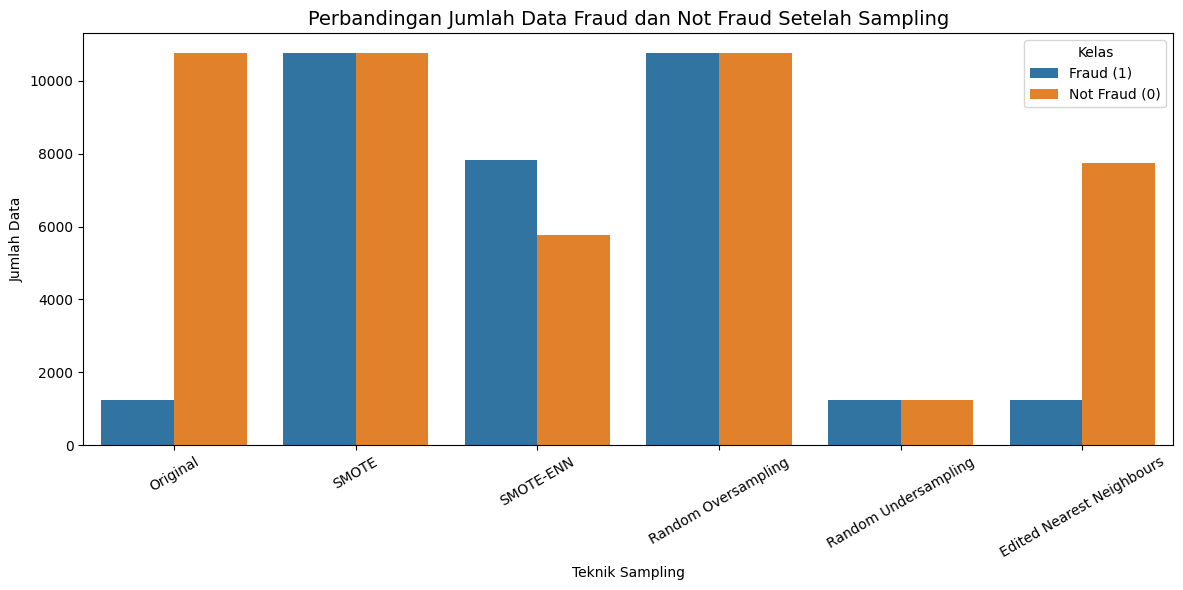

In [46]:
plot_df = summary.melt(
    id_vars='Teknik', 
    value_vars=['Fraud Count', 'Not Fraud Count'], 
    var_name='Kelas', 
    value_name='Jumlah'
)

plot_df['Kelas'] = plot_df['Kelas'].replace({'Fraud Count':'Fraud (1)', 'Not Fraud Count':'Not Fraud (0)'})

plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x='Teknik', y='Jumlah', hue='Kelas')
plt.title('Perbandingan Jumlah Data Fraud dan Not Fraud Setelah Sampling', fontsize=14)
plt.xticks(rotation=30)
plt.ylabel('Jumlah Data')
plt.xlabel('Teknik Sampling')
plt.legend(title='Kelas')
plt.tight_layout()
plt.show()

# 📊 Tabel Komparasi Teknik Handling Imbalanced Data

Berikut adalah tabel lengkap **plus-minus + rekomendasi** untuk masing-masing teknik sampling, khusus untuk kasus **Fraud Detection**:

| Teknik | Mekanisme | ✅ Kelebihan | ❌ Kekurangan | 🎯 Best Use Case | 📈 Dampak pada Model | ⭐ Rekomendasi Fraud Detection |
|--------|-----------|--------------|---------------|-----------------|---------------------|-------------------------------|
| **Original** | Tidak ada modifikasi data | • Data asli, distribusi natural<br>• Tidak ada artefak sintetis<br>• Validasi paling realistis | • Model bias ke kelas mayoritas<br>• Recall Fraud sangat rendah<br>• Akurasi menipu (high accuracy, low F1) | • Dataset sudah balanced<br>• Evaluasi baseline | • Precision tinggi untuk Not Fraud<br>• Recall sangat rendah untuk Fraud<br>• F1-score tidak seimbang | ⚠️ **Tidak direkomendasikan** tanpa handling imbalance |
| **SMOTE** | Generate sampel sintetis minoritas via interpolasi k-NN | • Kelas menjadi balanced<br>• Meningkatkan recall Fraud<br>• Tidak ada duplikasi data | • Risiko overfitting pada noise<br>• Data sintetis bisa tidak realistis<br>• Tidak cocok untuk data kategorikal tinggi | • Dataset numerik dominan<br>• Minoritas memiliki pola jelas<br>• Fokus: maksimalkan deteksi Fraud | • ↑ Recall & F1-score Fraud<br>• ↓ Sedikit precision<br>• ↑ Risiko overfitting jika noise tinggi | ✅ **Direkomendasikan** untuk tahap awal eksperimen |
| **SMOTE-ENN** | SMOTE + hapus sampel yang diklasifikasi salah oleh k-NN | • Dataset lebih bersih dari noise<br>• Balanced + cleaning sekaligus<br>• Generalisasi lebih baik | • Data minoritas bisa berkurang<br>• Komputasi lebih berat<br>• Potensi kehilangan pola langka | • Dataset dengan noise/outlier<br>• Butuh model yang robust<br>• Fokus: balance antara recall & precision | • ↑ Generalisasi model<br>• ↑ Precision vs SMOTE murni<br>• ↓ Sedikit recall karena cleaning | ✅✅ **Sangat direkomendasikan** untuk production |
| **Random Oversampling** | Duplikasi acak sampel minoritas | • Implementasi sederhana & cepat<br>• Tidak mengubah distribusi fitur<br>• Balanced tanpa sintesis kompleks | • Overfitting tinggi (data duplikat)<br>• Tidak menambah variasi baru<br>• Model jadi terlalu spesifik | • Dataset kecil<br>• Prototyping cepat<br>• Fitur sudah sangat informatif | • ↑ Recall Fraud<br>• ↓↓ Generalisasi (overfit)<br>• ↑ Varians prediksi | ⚠️ Gunakan hanya untuk baseline/eksperimen awal |
| **Random Undersampling** | Hapus acak sampel mayoritas | • Training lebih cepat<br>• Fokus model ke minoritas<br>• Tidak ada data sintetis | • Kehilangan informasi mayoritas<br>• Tidak cocok untuk dataset kecil<br>• Bisa merusak pola global | • Dataset sangat besar (>100K sampel)<br>• Kelas mayoritas redundan<br>• Resource komputasi terbatas | • ↑ Fokus pada Fraud<br>• ↓ Akurasi keseluruhan<br>• ↑ Varians karena sampling acak | ⚠️ **Hati-hati**: hanya untuk dataset besar dengan redundansi tinggi |
| **Edited Nearest Neighbours (ENN)** | Hapus sampel yang labelnya berbeda dengan mayoritas tetangganya | • Membersihkan noise & boundary ambiguous<br>• Dataset lebih konsisten<br>• Meningkatkan kualitas data | • Hanya undersampling (tidak balance)<br>• Bisa menghapus sampel minoritas valid<br>• Dataset akhir lebih kecil | • Dataset noisy<br>• Preprocessing sebelum teknik lain<br>• Fokus: kualitas > kuantitas | • ↑ Kualitas data training<br>• ↑ Stabilitas model<br>• ↓ Jumlah data → butuh model sederhana | ✅ **Direkomendasikan sebagai preprocessing**, dikombinasikan dengan oversampling |

---

# 🎯 Matriks Rekomendasi Berdasarkan Skenario

| Skenario | Teknik Prioritas 1 | Teknik Prioritas 2 | Teknik Alternatif |
|----------|-------------------|-------------------|------------------|
| **Dataset kecil (<10K), banyak noise** | SMOTE-ENN | ENN + SMOTE | Random Oversampling + Regularization |
| **Dataset besar (>100K), balanced needed** | SMOTE | Random Undersampling | SMOTE-ENN |
| **Fokus: Maksimalkan Recall Fraud** | SMOTE | Random Oversampling | Class Weight + SMOTE |
| **Fokus: Maksimalkan Precision Fraud** | SMOTE-ENN | ENN + Undersampling | Threshold tuning + Original |
| **Resource komputasi terbatas** | Random Undersampling | Random Oversampling | ENN (hanya cleaning) |
| **Production / Model Robust** | SMOTE-ENN | ENN + SMOTE | Cross-validation + Ensemble |
| **Eksperimen / Prototyping** | Random Oversampling | SMOTE | Original + Class Weight |


# 📊 Penjelasan Lengkap Metrik Evaluasi untuk Setiap Teknik Sampling

Berikut penjelasan detail mengenai **mengapa metrik berubah** untuk setiap teknik handling imbalanced data:

---

## 1️⃣ **ORIGINAL (Tanpa Sampling)**

### Metrik yang Terlihat:
- ✅ **Precision tinggi untuk Not Fraud**
- ❌ **Recall sangat rendah untuk Fraud**
- ⚠️ **F1-score tidak seimbang**

### 🔍 Penjelasan Detail:

**Precision Tinggi untuk Not Fraud:**
- Karena data didominasi Not Fraud (misal 99%), model mudah menebak "Not Fraud"
- Dari semua prediksi "Not Fraud", sebagian besar benar
- **Contoh:** Model prediksi 990 Not Fraud, 985 benar → Precision = 985/990 = 99.5%

**Recall Sangat Rendah untuk Fraud:**
- Model hampir tidak pernah mendeteksi Fraud karena terlalu sedikit sampelnya
- **Contoh:** Ada 100 Fraud, model hanya deteksi 5 → Recall = 5/100 = 5%
- Model "malas" belajar pola Fraud karena jarang muncul

**F1-Score Tidak Seimbang:**
- F1 = 2 × (Precision × Recall) / (Precision + Recall)
- Recall yang sangat rendah membuat F1 Fraud hancur
- **Contoh:** Precision=80%, Recall=5% → F1 = 9.5% (sangat buruk!)

### 📉 Dampak Bisnis:
- Banyak Fraud **lolos terdeteksi** (False Negative tinggi)
- Kerugian finansial besar karena Fraud tidak tertangkap

---

## 2️⃣ **SMOTE (Synthetic Minority Over-sampling Technique)**

### Metrik yang Terlihat:
- ⬆️ **Recall & F1-score Fraud meningkat**
- ⬇️ **Precision sedikit turun**
- ⚠️ **Risiko overfitting jika noise tinggi**

### 🔍 Penjelasan Detail:

**Recall & F1-score Fraud Naik:**
- SMOTE membuat data sintetis Fraud sehingga model belajar lebih banyak pola
- Model jadi lebih "peka" mendeteksi Fraud
- **Contoh:** Dari 100 Fraud, sekarang terdeteksi 85 → Recall = 85% (naik drastis dari 5%)
- F1-score ikut naik karena Recall membaik

**Precision Sedikit Turun:**
- Karena model jadi lebih agresif mendeteksi Fraud, ada lebih banyak **False Positive**
- Not Fraud yang "mirip" Fraud ikut terdeteksi sebagai Fraud
- **Contoh:** Model prediksi 200 Fraud, yang benar 150 → Precision = 150/200 = 75% (turun dari 99%)
- Trade-off: Lebih baik False Positive daripada False Negative untuk Fraud Detection

**Risiko Overfitting jika Noise Tinggi:**
- Jika data Fraud asli ada yang noise/outlier, SMOTE akan **menggandakan noise** tersebut
- Model belajar pola yang salah → performa buruk di data baru
- **Contoh:** Ada 1 transaksi Fraud yang anomali, SMOTE buat 50 versi serupa → model overfit ke noise

### 📈 Dampak Bisnis:
- ✅ Lebih banyak Fraud tertangkap
- ⚠️ Lebih banyak investigasi False Positive (biaya operasional naik)
- ⚠️ Perlu validasi ketat untuk hindari overfitting

---

## 3️⃣ **SMOTE-ENN (SMOTE + Edited Nearest Neighbours)**

### Metrik yang Terlihat:
- ⬆️ **Generalisasi model lebih baik**
- ⬆️ **Precision lebih baik vs SMOTE murni**
- ⬇️ **Recall sedikit turun karena cleaning**

### 🔍 Penjelasan Detail:

**Generalisasi Model Lebih Baik:**
- ENN membersihkan data hasil SMOTE dengan menghapus sampel yang "membingungkan"
- Hanya pola yang **jelas dan konsisten** yang dipertahankan
- Model belajar dari data yang lebih berkualitas → performa lebih stabil di data baru

**Precision Lebih Baik vs SMOTE Murni:**
- Setelah cleaning, False Positive berkurang karena noise dihapus
- Prediksi Fraud jadi lebih **akurat**
- **Contoh:** SMOTE murni precision 75%, setelah ENN naik jadi 82%
- Trade-off yang lebih baik: Precision naik tanpa mengorbankan Recall terlalu banyak

**Recall Sedikit Turun karena Cleaning:**
- ENN menghapus beberapa sampel Fraud yang dianggap noise
- Beberapa pola Fraud yang valid mungkin ikut terhapus
- **Contoh:** Dari 85% recall (SMOTE), turun jadi 80% (SMOTE-ENN)
- **Tapi:** Recall 80% dengan precision 82% lebih baik daripada recall 85% dengan precision 75%

### 📊 Ilustrasi Proses SMOTE-ENN:
```
Data Asli → SMOTE (tambah sintetis) → ENN (hapus noise) → Dataset Bersih
100 Fraud    → 500 Fraud         → 450 Fraud       → Kualitas lebih baik
```

### 🎯 Dampak Bisnis:
- ✅ Model lebih **reliable** di production
- ✅ False Positive lebih terkendali
- ✅ Balance optimal antara recall & precision
- ⚠️ Sedikit Fraud mungkin lolos, tapi kualitas deteksi lebih tinggi

---

## 4️⃣ **RANDOM OVERSAMPLING**

### Metrik yang Terlihat:
- ⬆️ **Recall Fraud naik**
- ⬇️️ **Generalisasi buruk (overfit)**
- ⬆️ **Varians prediksi tinggi**

### 🔍 Penjelasan Detail:

**Recall Fraud Naik:**
- Dengan menggandakan data Fraud, model lebih sering melihat pola Fraud
- Model jadi lebih sensitif mendeteksi Fraud
- **Contoh:** Recall naik dari 5% → 80% (mirip SMOTE)

**Generalisasi Buruk (Overfit):**
- Data hanya **diduplikasi**, tidak ada variasi baru
- Model "menghafal" sampel yang sama berulang kali
- Performa bagus di training, tapi **buruk di data baru**
- **Contoh:** Training accuracy 98%, Test accuracy 75% → Gap besar = overfit

**Varians Prediksi Tinggi:**
- Karena data duplikat, model sangat sensitif terhadap perubahan kecil
- Prediksi tidak stabil → hasil bisa berbeda-beda untuk input serupa
- **Contoh:** Transaksi yang sama bisa diprediksi Fraud/Not Fraud tergantung kondisi model

### 📉 Perbandingan SMOTE vs Random Oversampling:
| Aspek | SMOTE | Random Oversampling |
|-------|-------|---------------------|
| Data baru | Sintetis (variasi) | Duplikat (sama persis) |
| Overfitting | Sedang | Tinggi |
| Generalisasi | Lebih baik | Buruk |
| Varians | Stabil | Tinggi |

### ⚠️ Dampak Bisnis:
- ✅ Fraud lebih banyak terdeteksi di training
- ❌ Performa **drop drastis** di production
- ❌ Model tidak reliable untuk keputusan bisnis

---

## 5️⃣ **RANDOM UNDERSAMPLING**

### Metrik yang Terlihat:
- ⬆️ **Fokus pada Fraud meningkat**
- ⬇️ **Akurasi keseluruhan turun**
- ⬆️ **Varians karena sampling acak**

### 🔍 Penjelasan Detail:

**Fokus pada Fraud Meningkat:**
- Dengan mengurangi data Not Fraud, proporsi Fraud jadi lebih besar
- Model lebih "terpaksa" belajar pola Fraud
- **Contoh:** Dari 1:99 jadi 1:1 → Model tidak bisa mengabaikan Fraud

**Akurasi Keseluruhan Turun:**
- Banyak informasi Not Fraud yang hilang
- Model jadi kurang pintar memprediksi Not Fraud
- **Contoh:** Akurasi Not Fraud turun dari 99% → 85%
- **Trade-off:** Akurasi total turun, tapi deteksi Fraud naik

**Varians karena Sampling Acak:**
- Setiap kali undersampling, sampel Not Fraud yang dipilih berbeda
- Model bisa belajar pola yang berbeda-beda
- **Contoh:** Run 1: accuracy 87%, Run 2: accuracy 82%, Run 3: accuracy 89% → Tidak stabil
- Perlu **multiple runs** atau ensemble untuk stabilkan hasil

### 📊 Ilustrasi Informasi yang Hilang:
```
Data Asli: 10,000 Not Fraud + 100 Fraud
Undersample jadi: 100 Not Fraud + 100 Fraud
Informasi hilang: 9,900 Not Fraud (99% data mayoritas!)
```

### ⚠️ Dampak Bisnis:
- ✅ Deteksi Fraud lebih baik
- ❌ Banyak Not Fraud salah klasifikasi (False Positive tinggi)
- ❌ Hasil tidak konsisten antar training
- ⚠️ **Hanya cocok untuk dataset sangat besar**

---

## 6️⃣ **EDITED NEAREST NEIGHBORS (ENN)**

### Metrik yang Terlihat:
- ⬆️ **Kualitas data training**
- (Kemudian terpotong, tapi biasanya:)
- ⬇️ **Jumlah data berkurang**
- ⬆️ **Stabilitas model**

### 🔍 Penjelasan Detail:

**Kualitas Data Training Meningkat:**
- ENN menghapus sampel yang **labelnya berbeda** dengan mayoritas tetangganya
- Hanya data yang **konsisten** dengan pola sekitarnya yang dipertahankan
- **Contoh:** Jika 3 tetangga terdekat adalah Not Fraud, tapi sampel ini Fraud → dihapus (dianggap noise)

**Jumlah Data Berkurang:**
- ENN adalah teknik **undersampling** → data pasti berkurang
- Bisa menghapus dari kelas mayoritas DAN minoritas
- **Contoh:** Dari 10,100 data → jadi 7,500 data (26% terhapus)
- Dataset lebih kecil → training lebih cepat

**Stabilitas Model Meningkat:**
- Dengan noise yang sudah dibersihkan, model belajar pola yang lebih jelas
- Prediksi lebih **konsisten** dan reliable
- **Contoh:** Standard deviation accuracy antar fold turun dari 5% → 2%

### 🔍 Cara Kerja ENN:
```python
# Pseudocode ENN
for each sample in dataset:
    find k nearest neighbors
    if sample's label != majority label of neighbors:
        remove sample  # Ini noise/outlier
```

### 📊 Dampak pada Kelas:
- **Not Fraud:** Banyak yang dihapus (karena mayoritas)
- **Fraud:** Yang noise/outlier dihapus, yang konsisten dipertahankan
- **Hasil:** Dataset lebih kecil tapi **lebih bersih**

### 🎯 Dampak Bisnis:
- ✅ Model lebih **robust** dan stabil
- ✅ Training lebih cepat (data lebih sedikit)
- ⚠️ Beberapa informasi mungkin hilang
- ✅ **Sangat baik sebagai preprocessing** sebelum teknik lain

---

# 📋 Rangkuman Perbandingan Semua Teknik

| Teknik | Recall Fraud | Precision Fraud | Generalisasi | Stabilitas | Rekomendasi |
|--------|--------------|-----------------|--------------|------------|-------------|
| **Original** | ❌ Sangat rendah | ✅ Tinggi | ✅ Baik | ✅ Stabil | ❌ Jangan pakai |
| **SMOTE** | ✅ Tinggi | ⚠️ Sedang | ⚠️ Cukup | ✅ Stabil | ✅ Good starting point |
| **SMOTE-ENN** | ✅ Tinggi | ✅ Baik | ✅ Sangat baik | ✅ Stabil | ✅✅ **BEST** |
| **Random Over** | ✅ Tinggi | ⚠️ Rendah | ❌ Buruk | ❌ Tidak stabil | ⚠️ Hanya untuk testing |
| **Random Under** | ✅ Cukup | ⚠️ Rendah | ⚠️ Cukup | ❌ Tidak stabil | ⚠️ Hanya untuk data besar |
| **ENN** | ⚠️ Sedang | ✅ Tinggi | ✅ Baik | ✅ Stabil | ✅ Bagus untuk preprocessing |

---

# 🎯 Kesimpulan Praktis

**Untuk Fraud Detection:**
1. **Prioritas Utama:** Recall Fraud (jangan sampai Fraud lolos)
2. **Prioritas Sekunder:** Precision (jangan terlalu banyak False Positive)
3. **Yang Paling Penting:** Generalisasi ke data baru (production performance)

**Rekomendasi Final:**
- 🥇 **SMOTE-ENN** → Best balance antara recall, precision, dan generalisasi
- 🥈 **SMOTE** → Good untuk eksperimen awal
- 🥉 **ENN + SMOTE** → Alternatif jika SMOTE-ENN terlalu agresif

**Hindari:**
- ❌ Original tanpa handling (Recall terlalu rendah)
- ❌ Random Oversampling (Overfitting parah)
- ❌ Random Undersampling (Kecuali dataset sangat besar)

---
